In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

#### Functions

In [2]:
def plot_frequency(df, str_col):
    # freq
    ser_freq = df[str_col].value_counts(normalize=True)
    df_freq = ser_freq.reset_index()
    df_freq.columns = [str_col, 'Proportion']
    df_freq.sort_values(by=str_col, ascending=False, inplace=True)

    # plot
    x = df_freq[str_col]
    y = df_freq['Proportion']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Proportion {str_col} (N = {int_nrows})')
    ax.set_xlabel(str_col)
    ax.set_ylabel('Proportion')
    bars = ax.bar(x, y)
    ax.bar_label(bars, fmt='%.4f')

    # show
    plt.show()

In [3]:
def plot_distribution(df, str_col):
    list_tmp = list(df[str_col])
    int_n = len(list_tmp)
    flt_mn = np.mean(list_tmp)
    flt_mdn = np.median(list_tmp)
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Mn = {flt_mn:0.4f}; Mdn = {flt_mdn:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    sns.kdeplot(list_tmp, ax=ax)
    # show
    plt.show()

In [4]:
def plot_dv_by_iv(df, str_col_dv, str_col_iv):
    int_nrows = df.shape[0]
    # unique vals for iv
    list_str_val = list(df[str_col_iv].unique())
    # plot
    str_title = f'Distribution of {str_col_dv} by {str_col_iv} (N = {int_nrows})'
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col_dv)
    for str_val in tqdm(list_str_val):
        # subset
        df_tmp = df[df[str_col_iv] == str_val].copy()
        # list tmp
        list_tmp = list(df_tmp[str_col_dv])
        int_n = len(list_tmp)
        flt_mn = np.mean(list_tmp)
        flt_mdn = np.median(list_tmp)
        str_label = f'{str_val}: N={int_n}; Mn={flt_mn:0.2f}; Mdn={flt_mdn:0.2f}'
        # plot
        sns.kdeplot(list_tmp, label=str_label, ax=ax)
    # legend
    plt.legend()
    # show
    plt.show()

#### Constants

In [5]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

Project: 20241112-simple-model-test


#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/04_parse_payloads_dl/{str_filename}'
df = pd.read_parquet(str_uri)
# set dtm
df['request_datetime'] = pd.to_datetime(df['request_datetime'])
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,monthlyresidual70__bb,monthlyresidual58__bb,monthlyresidual51__bb,monthlyresidual68__bb,monthlyresidual57__bb,monthlyresidual53__bb,monthlyresidual65__bb,monthlyresidual47__bb,monthlyresidual60__bb,monthlyresidual64__bb
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,8425073/6dep-2024-11-26-00:01:11,1,8.425073e+15,8425073.0,10402471.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,8425080/l72Z-2024-11-26-00:03:27,1,8.425080e+15,8425080.0,10402481.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,8425104/c979-2024-11-26-00:09:16,1,8.425104e+15,8425104.0,10402507.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,8425136/6ga3-2024-11-26-00:18:35,1,8.425136e+15,8425136.0,10402546.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,8425173/r5q6-2024-11-26-00:29:46,1,8.425173e+15,8425173.0,10402592.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,8627588/9pLH-2025-02-06-23:40:52,1,NaN,NaN,NaN,1,Illinois,...,6275.0,6900.0,7800.0,6475.0,7050.0,7625.0,6650.0,8150.0,6650.0,6675.0
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,8627590/97E4-2025-02-06-23:41:04,1,NaN,NaN,NaN,1,Louisiana,...,12200.0,13675.0,14825.0,12525.0,13875.0,14625.0,12950.0,15400.0,13375.0,13050.0
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,8627613/yyYR-2025-02-06-23:47:03,1,NaN,NaN,NaN,1,Texas,...,11175.0,13300.0,15225.0,11675.0,13575.0,14775.0,12250.0,15975.0,12800.0,12450.0
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,8627659/8vmh-2025-02-06-23:57:18,1,NaN,NaN,NaN,1,Georgia,...,10975.0,12950.0,14800.0,11425.0,13250.0,14375.0,11975.0,15525.0,12525.0,12100.0


#### Date range

In [7]:
dtm_min = df['request_datetime'].min()
dtm_max = df['request_datetime'].max()
print(f'Date range: {dtm_min} - {dtm_max}')

Date range: 2024-11-26 07:01:11+00:00 - 2025-02-07 06:58:01+00:00


#### LTV

In [8]:
# amt financed
df['amtfinanced__app'] = df['amtfinanced__app'].replace(0, np.nan)
# book value
df['bookvalue__app'] = df['bookvalue__app'].replace(0, np.nan)
# LTV
df['ENG-loan_to_value'] = df['amtfinanced__app'] / df['bookvalue__app']
# impute
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].fillna(1.2734844012832087)
# clip
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].clip(upper=2)

#### Income

In [9]:
df['fltgrossmonthly__income_sum'] = df['fltgrossmonthly__income_sum'].fillna(0)
df['fltgrossmonthly__income_sum'] = df['fltgrossmonthly__income_sum'].clip(upper=11742.160000000047)

#### Miles

In [10]:
df['miles_odometer__app'] = df['miles_odometer__app'].replace(0, np.nan)
df['miles_odometer__app'] = df['miles_odometer__app'].fillna(60518.520779948754)
df['miles_odometer__app'] = df['miles_odometer__app'].clip(upper=200000)

#### Income at debtor level

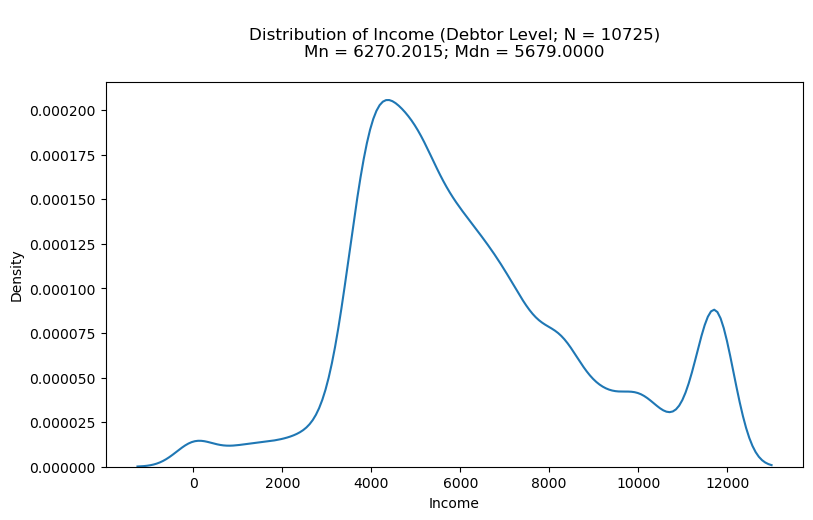

In [11]:
list_tmp = list(df['fltgrossmonthly__income_sum'])
int_n = len(list_tmp)
flt_mn = np.mean(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of Income (Debtor Level; N = {int_n})
Mn = {flt_mn:0.4f}; Mdn = {flt_mdn:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Income')
sns.kdeplot(list_tmp, ax=ax)
# show
plt.show()

#### Group

In [12]:
# group
df = df.groupby(by='accountid', as_index=False).agg({
    'ENG-loan_to_value': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
int_nrows = df.shape[0]
# show
df

,accountid,ENG-loan_to_value,fltgrossmonthly__income_sum,miles_odometer__app
0,8321703,1.304611,4379.20,69144.0
1,8353245,1.219764,8923.01,97249.0
2,8375603,1.101235,8233.33,56150.0
3,8380765,1.135986,6998.09,30237.0
4,8383502,0.954679,10034.96,52621.0
...,...,...,...,...
9995,8627588,1.243941,7401.00,40301.0
9996,8627590,1.217199,7500.00,79000.0
9997,8627613,0.993862,10833.00,42200.0
9998,8627659,0.967878,5400.00,86000.0


#### Plots

  0%|          | 0/3 [00:00<?, ?it/s]

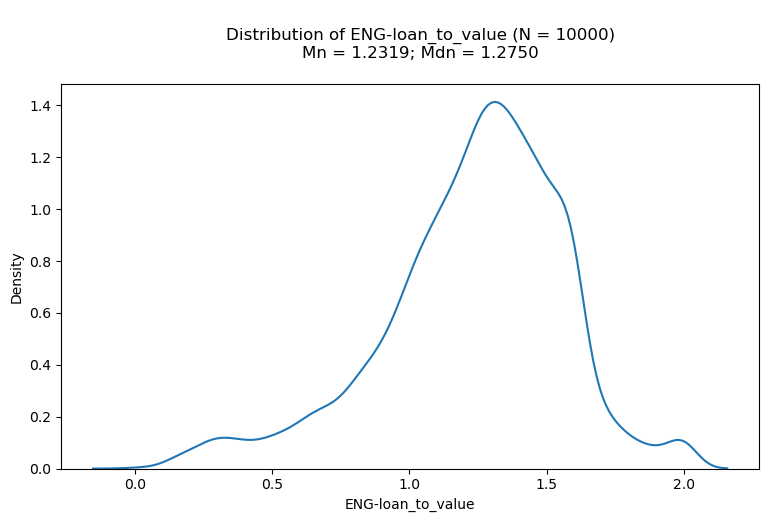

 33%|███▎      | 1/3 [00:00<00:00,  4.78it/s]

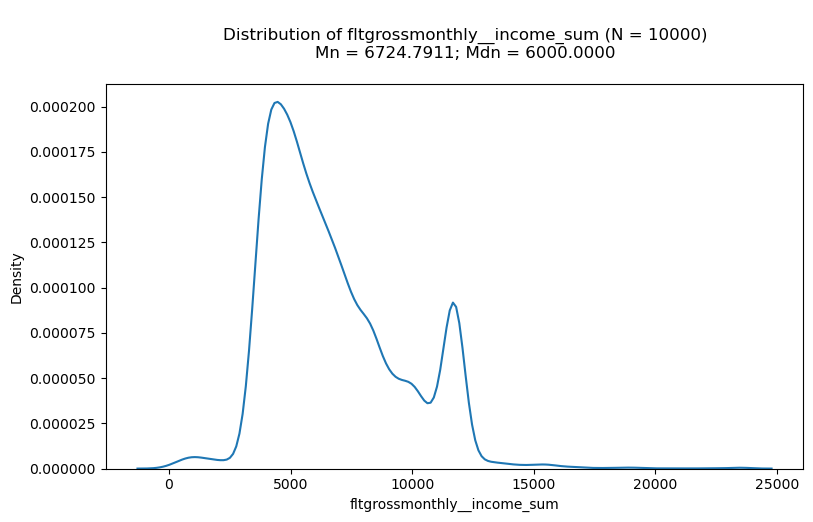

 67%|██████▋   | 2/3 [00:00<00:00,  4.44it/s]

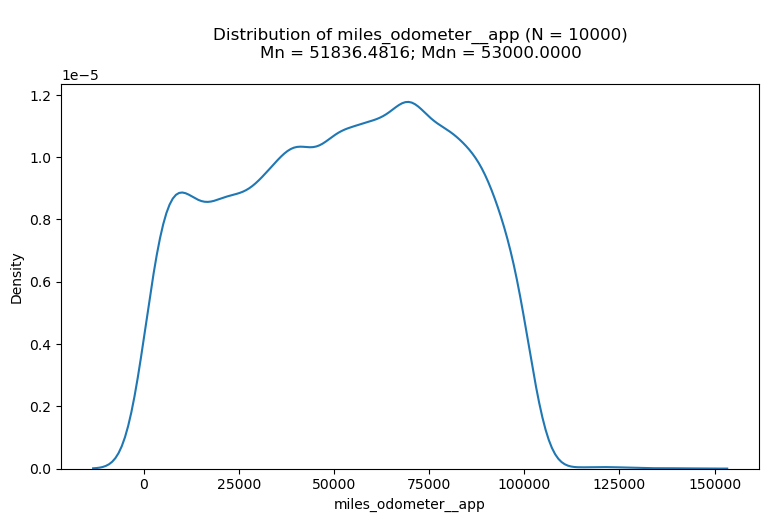

100%|██████████| 3/3 [00:00<00:00,  4.50it/s]


In [13]:
list_str_col = [
    'ENG-loan_to_value',
    'fltgrossmonthly__income_sum',
    'miles_odometer__app'
]
for str_col in tqdm(list_str_col):
    plot_distribution(
        df=df,
        str_col=str_col,
    )